In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("ai-impact-jobs-layoff-risk-dataset.csv")

In [4]:
df.sample(5)

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
2491,59,High School,13,Education,Teacher,Medium,Mid,93,2,65,Medium,2,9,59,21,High
11391,50,Bachelor's,0,IT,Software Engineer,Large,Mid,31,67,66,Low,0,1,27,3,Low
2965,56,Bachelor's,8,Finance,Accountant,Small,Entry,52,54,39,Low,0,0,27,0,Medium
9672,40,High School,11,Finance,Accountant,Medium,Entry,85,0,31,High,10,28,47,70,High
890,21,High School,0,Manufacturing,Quality Engineer,Medium,Mid,62,46,89,Medium,4,11,30,27,High


In [5]:
df.shape

(20000, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [7]:
df.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df_clean = df.copy()

In [10]:
for col in df_clean.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print("-"*50)

Education_Level
["Master's" "Bachelor's" 'High School' 'PhD']
--------------------------------------------------
Industry
['Finance' 'Manufacturing' 'Retail' 'Telecom' 'IT' 'Logistics'
 'Healthcare' 'Education']
--------------------------------------------------
Job_Role
['Accountant' 'Production Supervisor' 'Store Manager' 'Auditor'
 'Network Engineer' 'Software Engineer' 'ML Engineer' 'Inventory Analyst'
 'Dispatcher' 'Health Analyst' 'Support Specialist' 'Sales Associate'
 'Academic Coordinator' 'Financial Analyst' 'Operator'
 'Research Assistant' 'Quality Engineer' 'Teacher' 'Warehouse Manager'
 'Supply Chain Analyst' 'Operations Analyst' 'Medical Assistant' 'Nurse'
 'Data Analyst']
--------------------------------------------------
Company_Size
['Medium' 'Small' 'Large']
--------------------------------------------------
Job_Level
['Entry' 'Senior' 'Mid']
--------------------------------------------------
AI_Adoption_Level
['Medium' 'Low' 'High']
----------------------------------

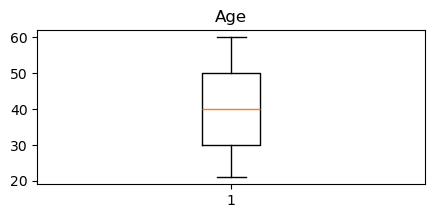

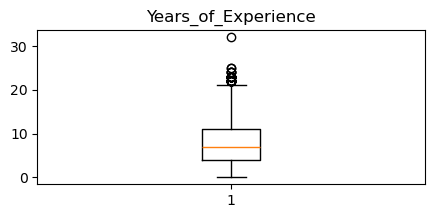

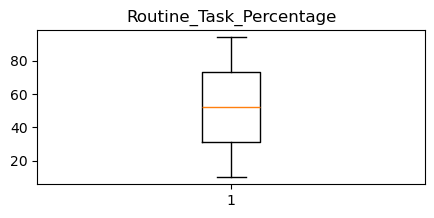

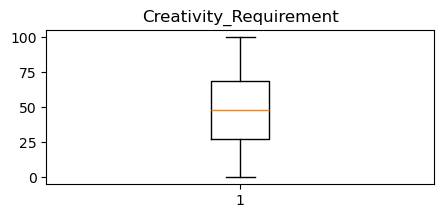

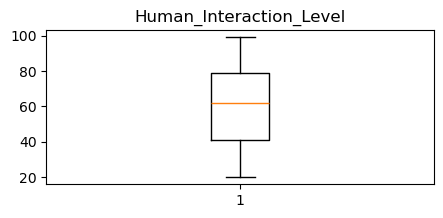

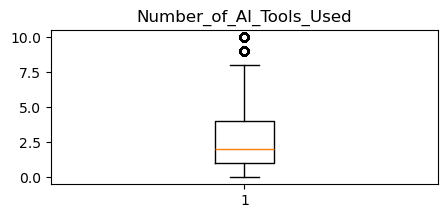

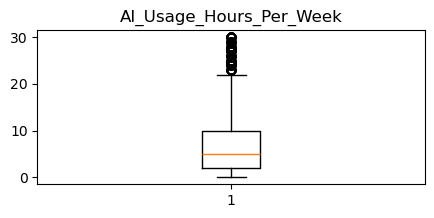

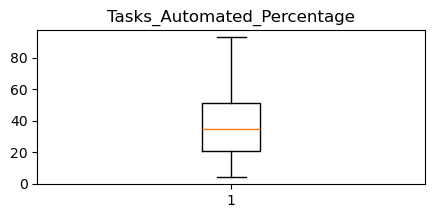

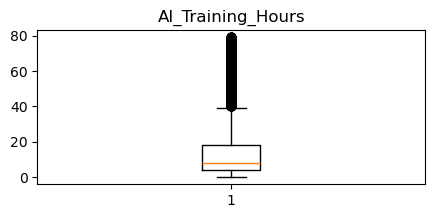

In [11]:
import matplotlib.pyplot as plt

num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(5,2))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [13]:
df['Layoff_Risk'].value_counts()

Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64

<Axes: xlabel='Layoff_Risk'>

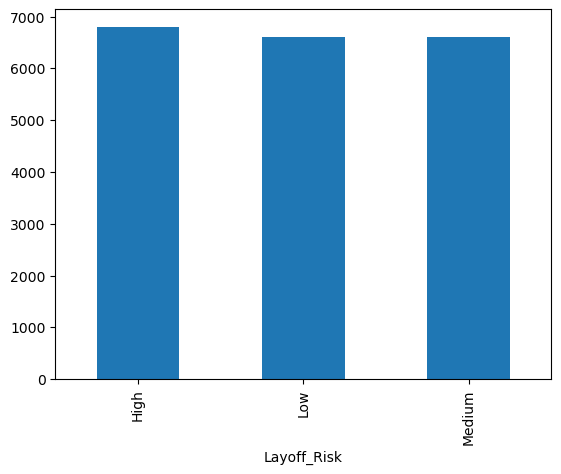

In [14]:
df['Layoff_Risk'].value_counts().plot(kind='bar')

In [15]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].nunique())

Education_Level 4
Industry 8
Job_Role 24
Company_Size 3
Job_Level 3
AI_Adoption_Level 3
Layoff_Risk 3


In [38]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
le = LabelEncoder()

for col in df_clean.select_dtypes(include='object'):
    df_clean[col] = le.fit_transform(df[col])

In [18]:
df_clean.sample(5)

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
19717,27,1,4,2,9,2,0,59,37,93,2,5,6,37,8,2
8557,25,2,1,5,14,1,0,77,28,62,2,2,14,55,27,0
2136,37,0,11,2,9,0,1,61,29,94,2,5,10,52,21,2
2229,24,1,3,3,8,0,0,93,5,78,2,2,10,90,20,0
9310,48,0,9,6,19,1,0,32,63,66,1,2,0,17,4,2


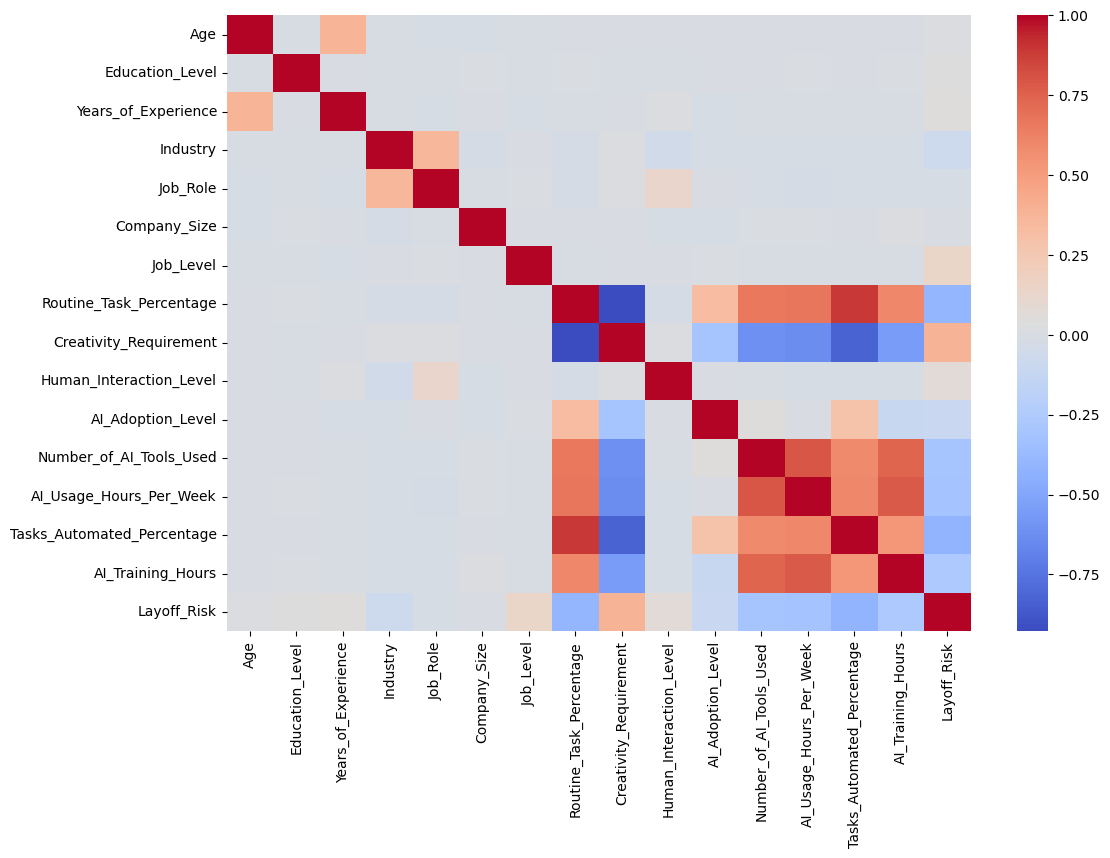

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), cmap='coolwarm')
plt.show()

In [21]:
corr = df_clean.corr()['Layoff_Risk'].sort_values(ascending=False)
print(corr)

Layoff_Risk                   1.000000
Creativity_Requirement        0.388800
Job_Level                     0.135724
Human_Interaction_Level       0.071230
Years_of_Experience           0.050255
Education_Level               0.038634
Age                           0.016998
Company_Size                  0.004020
Job_Role                     -0.014874
Industry                     -0.071443
AI_Adoption_Level            -0.104123
AI_Training_Hours            -0.269250
Number_of_AI_Tools_Used      -0.303622
AI_Usage_Hours_Per_Week      -0.312949
Routine_Task_Percentage      -0.406111
Tasks_Automated_Percentage   -0.419292
Name: Layoff_Risk, dtype: float64


In [25]:
X = df_clean.drop('Layoff_Risk', axis=1)
y = df_clean['Layoff_Risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

C:\Users\ASUS\anaconda3\envs\cv_project\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.83825

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.88925
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1375
           1       0.93      0.92      0.92      1296
           2       0.84      0.83      0.83      1329

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.931
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1375
           1       0.96      0.95      0.95      1296
           2       0.89      0.91      0.90      1329

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



Routine_Task_Percentage       0.320094
Job_Level                     0.130994
Tasks_Automated_Percentage    0.119718
Education_Level               0.081969
Industry                      0.081563
Creativity_Requirement        0.075224
Years_of_Experience           0.047022
Human_Interaction_Level       0.043218
Job_Role                      0.039562
AI_Adoption_Level             0.015386
AI_Training_Hours             0.012626
AI_Usage_Hours_Per_Week       0.009390
Number_of_AI_Tools_Used       0.008477
Age                           0.007834
Company_Size                  0.006922
dtype: float32


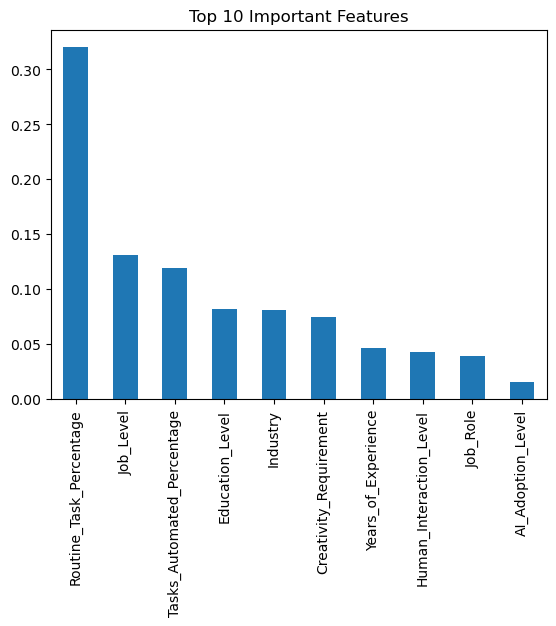

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

In [40]:
import joblib
joblib.dump(encoders, 'label_encoders.pkl')
joblib.dump(xgb, 'layoff_risk_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

['feature_names.pkl']